In [2]:
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))   # lista vacía = CPU

# ---------- Rutas: se detecta la raíz del proyecto (la carpeta que contiene 'datasets') ----------
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "datasets").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(f"No encontré la carpeta 'datasets' subiendo desde {Path.cwd()}")

DATA_ROOT  = PROJECT_ROOT / "datasets" / "animal_data"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE  = (224, 224)
BATCH     = 32
AUTOTUNE  = tf.data.AUTOTUNE

TensorFlow: 2.21.0
GPUs: []


In [3]:
# Si las clases están dentro de una subcarpeta extra (animal_data/animal_data/Bear), la detecta
if not any(d.name.lower() == "bear" for d in DATA_ROOT.iterdir() if d.is_dir()):
    for root, dirs, _ in os.walk(DATA_ROOT):
        if any(d.lower() == "bear" for d in dirs):
            DATA_ROOT = Path(root); break

print("Dataset en:", DATA_ROOT.resolve())
class_names = sorted(d.name for d in DATA_ROOT.iterdir() if d.is_dir())
NUM_CLASSES = len(class_names)
print(NUM_CLASSES, "clases:", class_names)

Dataset en: C:\Users\Lenovo\Documents\Universidad\Semestres\6\S. I\NNApp-main\datasets\animal_data
15 clases: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


In [4]:
# Lista de archivos válidos (se descartan imágenes corruptas)
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
paths, labels, skipped = [], [], 0
for idx, cname in enumerate(class_names):
    for f in sorted((DATA_ROOT / cname).iterdir()):
        if f.suffix.lower() not in EXTS:
            continue
        try:
            with Image.open(f) as im:
                im.verify()
            paths.append(str(f)); labels.append(idx)
        except Exception:
            skipped += 1
print(f"{len(paths)} imágenes válidas, {skipped} descartadas")

paths, labels = np.array(paths), np.array(labels)

# Split estratificado 70 / 15 / 15 (sin solapamiento)
p_train, p_tmp, y_train, y_tmp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
p_val, p_test, y_val, y_test = train_test_split(
    p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

assert not (set(p_train) & set(p_val) | set(p_train) & set(p_test) | set(p_val) & set(p_test))
print("train:", len(p_train), "| val:", len(p_val), "| test:", len(p_test))
print("Clases en val:", len(set(y_val)), "| clases en test:", len(set(y_test)))

1944 imágenes válidas, 0 descartadas
train: 1360 | val: 292 | test: 292
Clases en val: 15 | clases en test: 15


In [5]:
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_ds(p, y, training):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if training:
        ds = ds.shuffle(len(p), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE).batch(BATCH)
    return ds.prefetch(AUTOTUNE)

train_ds = make_ds(p_train, y_train, training=True)
val_ds   = make_ds(p_val,   y_val,   training=False)
test_ds  = make_ds(p_test,  y_test,  training=False)   # sin shuffle: el orden coincide con y_test

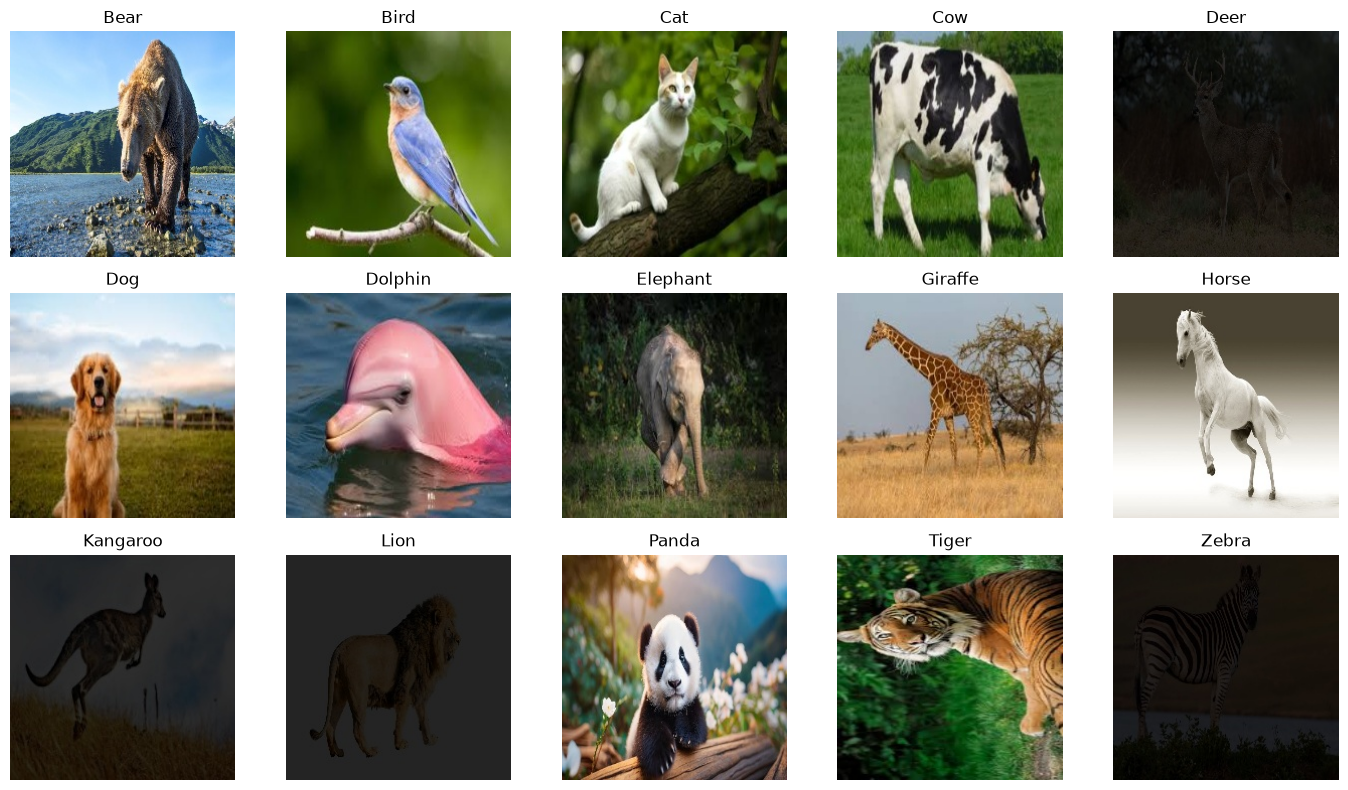

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for ax, (i, cname) in zip(axes.ravel(), enumerate(class_names)):
    sample = random.choice(paths[labels == i])
    ax.imshow(Image.open(sample)); ax.set_title(cname); ax.axis("off")
plt.tight_layout(); plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
def get_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ModelCheckpoint(str(MODELS_DIR / "best_animal_model.keras"), monitor="val_loss", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    ]

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=get_callbacks())

Epoch 1/15


c:\Users\Lenovo\Documents\Universidad\Semestres\6\S. I\NNApp-main\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


43/43 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4471 - loss: 1.9138 - val_accuracy: 0.8527 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 900ms/step - accuracy: 0.8088 - loss: 0.7216 - val_accuracy: 0.9315 - val_loss: 0.4027 - learning_rate: 0.0010
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 35s 805ms/step - accuracy: 0.8809 - loss: 0.4796 - val_accuracy: 0.9486 - val_loss: 0.2821 - learning_rate: 0.0010
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 883ms/step - accuracy: 0.8993 - loss: 0.3736 - val_accuracy: 0.9418 - val_loss: 0.2465 - learning_rate: 0.0010
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 779ms/step - accuracy: 0.9191 - loss: 0.3095 - val_accuracy: 0.9452 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 675ms/step - accuracy: 0.9279 - loss: 0.2651 - val_accuracy: 0.9555 - val_loss: 0.2054 - learning_rate: 0.0010
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 670ms/step - accuracy: 0.9272 - loss: 0.2567 - val_acc

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=get_callbacks())

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8926 - loss: 0.3696 - val_accuracy: 0.9589 - val_loss: 0.1402 - learning_rate: 1.0000e-05
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9221 - loss: 0.2882 - val_accuracy: 0.9589 - val_loss: 0.1377 - learning_rate: 1.0000e-05
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9294 - loss: 0.2558 - val_accuracy: 0.9589 - val_loss: 0.1351 - learning_rate: 1.0000e-05
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9338 - loss: 0.2240 - val_accuracy: 0.9589 - val_loss: 0.1335 - learning_rate: 1.0000e-05
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9529 - loss: 0.1961 - val_accuracy: 0.9623 - val_loss: 0.1322 - learning_rate: 1.0000e-05
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9669 - loss: 0.1574 - val_accuracy: 0.9623 - val_loss: 0.1342 - learning_rate: 1.0000e-05
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9596 - lo

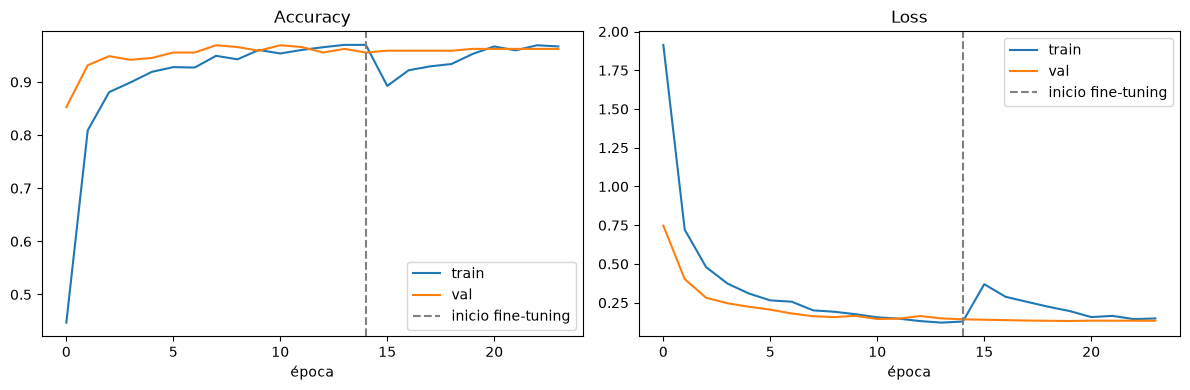

In [10]:
acc  = history.history["accuracy"]     + history_ft.history["accuracy"]
vacc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history.history["loss"]         + history_ft.history["loss"]
vloss= history.history["val_loss"]     + history_ft.history["val_loss"]
n1 = len(history.history["accuracy"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (t, v, name) in zip(ax, [(acc, vacc, "Accuracy"), (loss, vloss, "Loss")]):
    a.plot(t, label="train"); a.plot(v, label="val")
    a.axvline(n1 - 1, color="gray", ls="--", label="inicio fine-tuning")
    a.set_title(name); a.set_xlabel("época"); a.legend()
plt.tight_layout(); plt.show()

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
labels_idx = list(range(NUM_CLASSES))
print(classification_report(y_test, y_pred, labels=labels_idx, target_names=class_names))


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 807ms/step - accuracy: 0.9486 - loss: 0.1836
Test accuracy: 0.9486
              precision    recall  f1-score   support

        Bear       0.82      1.00      0.90        18
        Bird       0.95      1.00      0.98        21
         Cat       0.94      0.94      0.94        18
         Cow       0.87      1.00      0.93        20
        Deer       0.94      0.89      0.92        19
         Dog       0.89      0.89      0.89        19
     Dolphin       1.00      0.89      0.94        19
    Elephant       1.00      1.00      1.00        20
     Giraffe       1.00      0.90      0.95        20
       Horse       1.00      0.85      0.92        20
    Kangaroo       0.89      0.89      0.89        19
        Lion       0.95      0.95      0.95        19
       Panda       1.00      1.00      1.00        20
       Tiger       1.00      1.00      1.00        19
       Zebra       1.00      1.00      1.00        21

    accuracy                        

In [12]:
model.save(MODELS_DIR / "modelo_animales.keras")
print("Modelo guardado en", MODELS_DIR / "modelo_animales.keras")

def predict_image(path):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    arr = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
    probs = model.predict(arr, verbose=0)[0]
    top = np.argsort(probs)[::-1][:3]
    return [(class_names[i], float(probs[i])) for i in top]

# print(predict_image("mi_foto.jpg"))

Modelo guardado en c:\Users\Lenovo\Documents\Universidad\Semestres\6\S. I\NNApp-main\models\modelo_animales.keras
